# Module 5 / Class 2 -- When K-Means Fails: DBSCAN Comparison

**Objectives:**
- See K-Means fail on non-spherical data
- Understand how DBSCAN works (density-based clustering)
- Compare K-Means, DBSCAN, and Agglomerative Clustering side by side

In [ ]:
import numpy as np  # Import numpy library for performant array manipulation, linear algebra operations, and structural mathematical foundations
import matplotlib.pyplot as plt  # Import matplotlib.pyplot to construct coordinates, static plot charts, and figure canvasses
from sklearn.datasets import make_moons  # Import make_moons to generate a synthetic 2D dataset composed of two interleaving half-circle structures
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering  # Import distinct partitioning, density-based, and hierarchical clustering algorithms
from sklearn.preprocessing import StandardScaler  # Import StandardScaler to normalize features by removing the mean and scaling to unit variance

np.random.seed(42)  # Initialize a global pseudo-random number generator seed to guarantee identical array generations across script executions

## 1. Generate Crescent-Shaped Data

`make_moons` creates two interleaving half-circles. This is a classic example where centroid-based methods struggle.

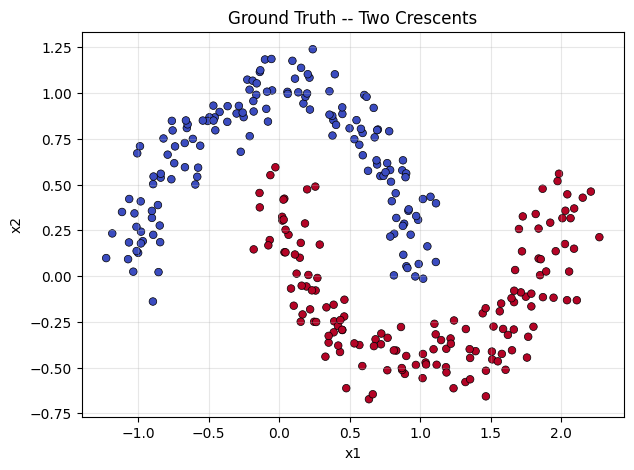

In [ ]:
X, y_true = make_moons(n_samples=300, noise=0.1, random_state=42)  # Generate a synthetic 2D dataset consisting of 300 samples shaped as two interleaving half-moon shapes with added Gaussian noise

plt.figure(figsize=(7, 5))  # Initialize a new figure canvas with a width of 7 inches and a height of 5 inches
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=30, edgecolors='black', linewidths=0.5)  # Render a scatter plot using a divergent color map to visually separate the ground truth crescent memberships
plt.title('Ground Truth -- Two Crescents')  # Assign a descriptive title label confirming the underlying non-linear distribution of the data
plt.xlabel('x1')  # Assign a descriptive label to the horizontal axis to denote the first feature dimension
plt.ylabel('x2')  # Assign a descriptive label to the vertical axis to denote the second feature dimension
plt.grid(True, alpha=0.3)  # Overlay a muted coordinate grid background at 30% opacity to aid in evaluating structural boundaries
plt.show()  # Display the completed crescent scatter plot on screen and clear the active figure state

## 2. K-Means (k=2) -- The Failure Case

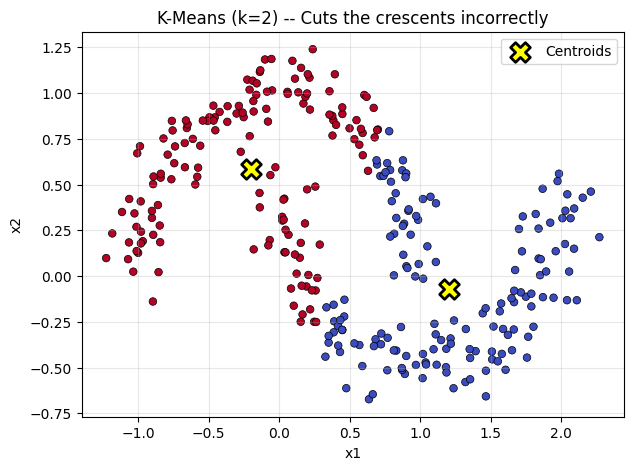

In [ ]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)  # Initialize a KMeans model to partition the data into 2 clusters using 10 random restarts
km_labels = kmeans.fit_predict(X)  # Fit the model and compute the cluster assignments for each sample in the crescent dataset

plt.figure(figsize=(7, 5))  # Initialize a new figure canvas with a width of 7 inches and a height of 5 inches
plt.scatter(X[:, 0], X[:, 1], c=km_labels, cmap='coolwarm', s=30, edgecolors='black', linewidths=0.5)  # Render the data points colored by their spherical KMeans cluster assignments
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', marker='X', edgecolors='black', linewidths=2, label='Centroids')  # Superimpose prominent yellow 'X' markers to mark the final locations of the cluster centroids
plt.title('K-Means (k=2) -- Cuts the crescents incorrectly')  # Assign a descriptive title highlighting KMeans' struggle with non-linearly separable structures
plt.xlabel('x1')  # Assign a descriptive label to the horizontal axis to denote the first feature dimension
plt.ylabel('x2')  # Assign a descriptive label to the vertical axis to denote the second feature dimension
plt.legend()  # Superimpose a visual legend matching label definitions to the centroid plot marker
plt.grid(True, alpha=0.3)  # Overlay a muted coordinate grid background at 30% opacity to assist with spatial tracking
plt.show()  # Display the completed cluster partition visualization on screen and clear the active figure state

K-Means draws a straight line between centroids. It cannot capture the curved shape of the crescents.

## 3. DBSCAN -- Density-Based Clustering

**Key parameters:**
- `eps`: maximum distance between two points to be considered neighbors
- `min_samples`: minimum number of points in a neighborhood to form a core point

DBSCAN does not require you to specify k. It discovers clusters based on density.

DBSCAN found 2 clusters and 0 noise points


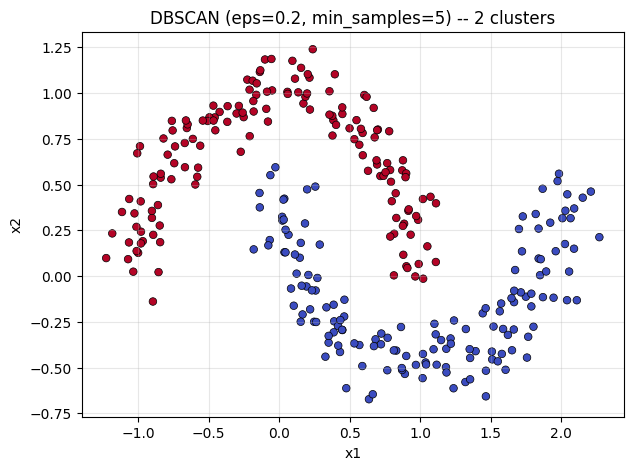

In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=5)  # Initialize a density-based spatial clustering model with a search radius of 0.2 and a minimum neighborhood density threshold of 5 points
db_labels = dbscan.fit_predict(X)  # Compute core density regions and assign corresponding cluster index or noise labels to each coordinate sample

n_clusters = len(set(db_labels) - {-1})  # Determine the total number of valid clusters discovered by isolating unique labels and removing the outlier designation index (-1)
n_noise = (db_labels == -1).sum()  # Count the total number of unassigned coordinates flagged as low-density noise artifacts
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points")  # Output the total count of discovered clusters and isolated noise samples to the console

plt.figure(figsize=(7, 5))  # Initialize a new figure canvas with a width of 7 inches and a height of 5 inches
plt.scatter(X[:, 0], X[:, 1], c=db_labels, cmap='coolwarm', s=30, edgecolors='black', linewidths=0.5)  # Render a scatter plot using a divergent color map to display density-connected cluster structures

# Mark noise points  # Define a conditional control comment for explicitly plotting unclustered outlier data
noise_mask = db_labels == -1  # Construct a boolean mask tracking the exact index positions of isolated noise artifacts
if noise_mask.any():  # Evaluate whether any unassigned outlier points exist within the dataset array
    plt.scatter(X[noise_mask, 0], X[noise_mask, 1], c='gray', s=30, marker='x', label='Noise')  # Superimpose gray 'x' markers over the coordinates identified as background noise
    plt.legend()  # Render the plot legend mapping the noise marker definition to the chart canvas
plt.title(f'DBSCAN (eps=0.2, min_samples=5) -- {n_clusters} clusters')  # Assign a descriptive title label summarizing hyperparameter values and the final cluster count
plt.xlabel('x1')  # Assign a descriptive label to the horizontal axis to denote the first feature dimension
plt.ylabel('x2')  # Assign a descriptive label to the vertical axis to denote the second feature dimension
plt.grid(True, alpha=0.3)  # Overlay a muted coordinate grid background at 30% opacity to assist with spatial inspection
plt.show()  # Display the completed density-based clustering visualization on screen and clear the active figure instance

## 4. Agglomerative Clustering

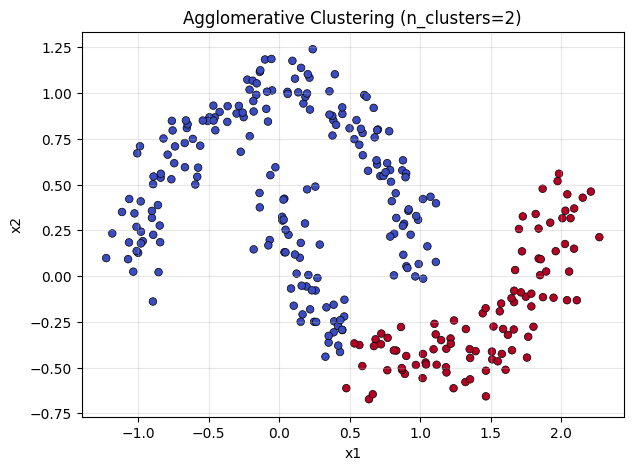

In [ ]:
agg = AgglomerativeClustering(n_clusters=2)  # Initialize a hierarchical bottom-up clustering model configured to recursively merge data points until 2 terminal clusters remain
agg_labels = agg.fit_predict(X)  # Build the hierarchical tree structure and extract the corresponding cluster labels for each sample in the dataset

plt.figure(figsize=(7, 5))  # Initialize a new figure canvas with a width of 7 inches and a height of 5 inches
plt.scatter(X[:, 0], X[:, 1], c=agg_labels, cmap='coolwarm', s=30, edgecolors='black', linewidths=0.5)  # Render a scatter plot using a divergent color map to visually separate the resolved hierarchical cluster boundaries
plt.title('Agglomerative Clustering (n_clusters=2)')  # Assign a descriptive main title indicating the algorithm type and target cluster count hyperparameter
plt.xlabel('x1')  # Assign a descriptive label to the horizontal axis to denote the first feature dimension
plt.ylabel('x2')  # Assign a descriptive label to the vertical axis to denote the second feature dimension
plt.grid(True, alpha=0.3)  # Overlay a muted coordinate grid background at 30% opacity to assist with spatial inspection and structural distribution tracking
plt.show()  # Display the completed hierarchical clustering visualization on screen and clear the active figure state

## 5. Side-by-Side Comparison

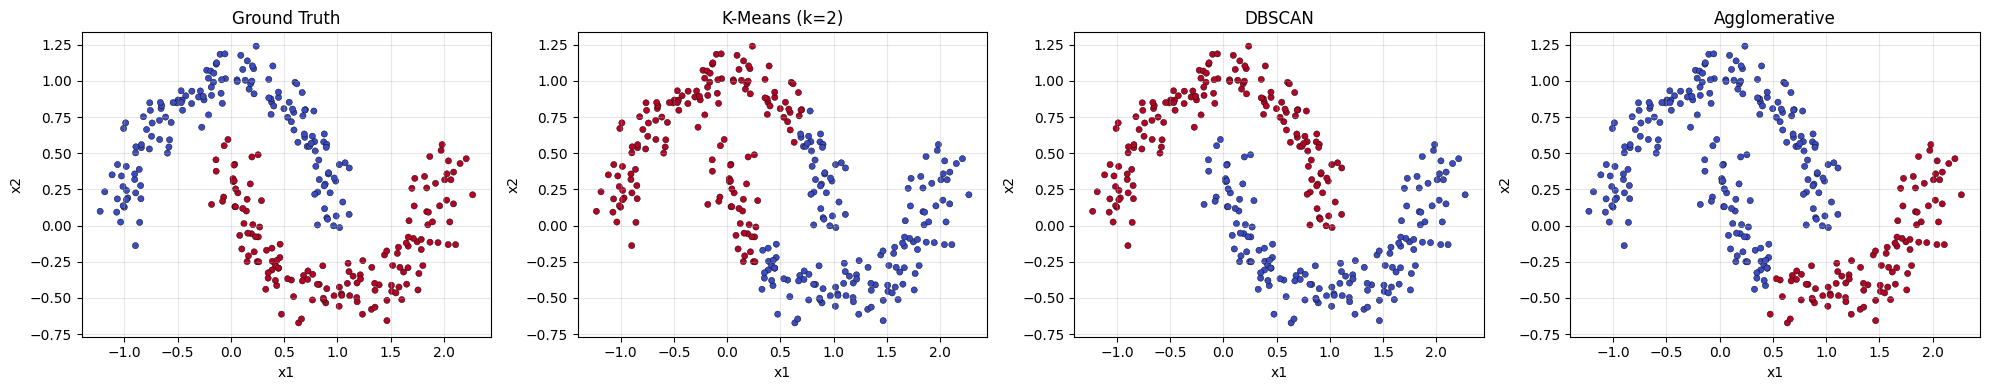

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))  # Initialize a multi-panel figure layout containing 1 row and 4 distinct subplots for a side-by-side performance audit

titles = ['Ground Truth', 'K-Means (k=2)', 'DBSCAN', 'Agglomerative']  # Define an ordered sequence of descriptive header titles mapping to each evaluated clustering method
all_labels = [y_true, km_labels, db_labels, agg_labels]  # Group the respective target ground truth arrays and calculated algorithm label arrays into a single matching sequence

for ax, title, lbls in zip(axes, titles, all_labels):  # Unpack and iterate simultaneously over the subplot axes, title strings, and resolved prediction arrays
    ax.scatter(X[:, 0], X[:, 1], c=lbls, cmap='coolwarm', s=20, edgecolors='black', linewidths=0.3)  # Render a scatter plot on the active subplot panel using a divergent color map to display cluster structures
    ax.set_title(title)  # Assign the corresponding model or dataset description string as the title header for the active subplot panel
    ax.set_xlabel('x1')  # Assign a descriptive label to the horizontal axis to denote the first feature dimension across all subplots
    ax.set_ylabel('x2')  # Assign a descriptive label to the vertical axis to denote the second feature dimension across all subplots
    ax.grid(True, alpha=0.3)  # Overlay a muted coordinate grid background at 30% opacity on each panel to assist with uniform spatial comparison

plt.tight_layout()  # Automatically optimize padding spaces and bounding boxes between all adjacent subplot panels to prevent text clipping
plt.show()  # Display the final four-panel algorithm comparison canvas on screen and reset the global figure memory state

## Summary

| Method | Needs k? | Handles Non-Spherical? | Handles Noise? |
|--------|----------|----------------------|----------------|
| K-Means | Yes | No | No |
| DBSCAN | No | Yes | Yes (marks as -1) |
| Agglomerative | Yes | Depends on linkage | No |

---

## TODO: Student Work

### Explain WHY K-Means fails on this data

In the cell below, write a clear explanation covering:
1. What assumption does K-Means make about cluster shapes?
2. Why does that assumption break for crescent/moon-shaped data?
3. How does DBSCAN avoid this problem?
4. In what scenario would you still prefer K-Means over DBSCAN?

# TODO: Write your explanation here

1. K-Means assumes...
2. This breaks because...
3. DBSCAN avoids this by...
4. I would still prefer K-Means when...

In [ ]:
# 1.  **What assumption does K-Means make about cluster shapes?**
#     K-Means assumes that clusters are spherical (or globular) and convex, with similar variance, and that the data points within each cluster are spread evenly around a central centroid. It tries to partition data into Voronoi cells, where each point is assigned to the nearest centroid.

# 2.  **Why does that assumption break for crescent/moon-shaped data?**
#     Crescent or moon-shaped data, by their very nature, are non-spherical and non-convex. When K-Means tries to fit spherical clusters to such data, it fails to separate the distinct, curved shapes. Instead, it tends to draw a straight line or boundary between the centroids, incorrectly splitting the curved clusters into two parts, as seen in the visualization. It cannot capture the intrinsic geometry of the data.

# 3.  **How does DBSCAN avoid this problem?**
#     DBSCAN (Density-Based Spatial Clustering of Applications with Noise) avoids this problem because it does not make assumptions about cluster shapes. Instead, it identifies clusters based on the density of data points. It groups together points that are closely packed together (core points), marking as outliers (noise) points that lie alone in low-density regions. This allows it to discover arbitrarily shaped clusters, including the crescent shapes, by connecting dense regions.

# 4.  **In what scenario would you still prefer K-Means over DBSCAN?**
#     You would still prefer K-Means over DBSCAN in scenarios where:
#     *   **Clusters are truly spherical or globular**: If the data naturally forms compact, well-separated, and spherical clusters.
#     *   **Computational efficiency**: For very large datasets, K-Means can be significantly faster than DBSCAN, especially if the dimensionality is high, as DBSCAN's complexity can increase with density queries.
#     *   **Consistent cluster size/density**: K-Means performs well when clusters have similar sizes and densities, whereas DBSCAN can struggle if clusters have vastly different densities (requiring different `eps` values).
#     *   **Predictable number of clusters (k is known)**: If the number of clusters is known beforehand or can be determined through domain knowledge or methods like the elbow method or silhouette score, K-Means is a straightforward choice.